TASK 1: Data Exploration and Preprocessing

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Airbnb_data.csv")

# Display basic info
print(" Dataset Info:")
print(df.info())

# First 5 rows
print("\n First few rows:")
print(df.head())

# Missing values
print("\n Missing values:")
print(df.isnull().sum())

# Summary stats
print("\n Summary statistics:")
print(df.describe(include='all'))



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified 

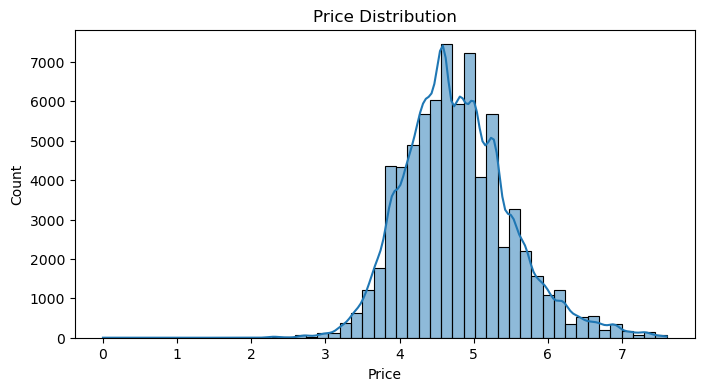

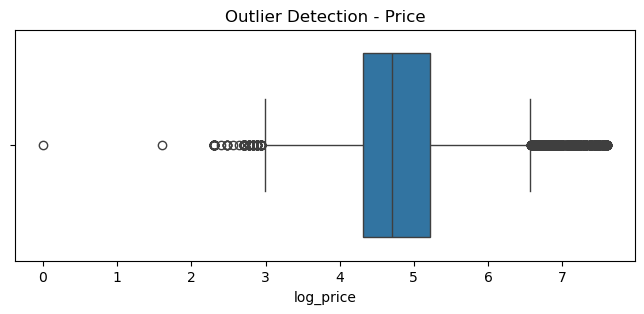

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Price distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# Boxplot to spot outliers
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['log_price'])
plt.title("Outlier Detection - Price")
plt.show()


In [7]:
# Drop rows with missing price or key fields
df_clean = df.dropna(subset=['log_price', 'room_type', 'property_type'])

# Remove extreme outliers
df_clean = df_clean[df_clean['log_price'] < df_clean['log_price'].quantile(0.99)]

# Fill missing numeric columns with median 
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())


TASK 2:Model Development

In [9]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the cleaned dataframe
df_label = df_clean.copy()

# Identify categorical columns
cat_cols = df_label.select_dtypes(include=['object']).columns.tolist()

# Excluded non-feature columns 
cat_cols = [col for col in cat_cols if col not in ['log_price', 'id', 'name', 'description']]  # adjust as needed

# Apply label encoding to each categorical column
le = LabelEncoder()
for col in cat_cols:
    df_label[col] = df_label[col].astype(str)  # ensure all entries are strings
    df_label[col] = le.fit_transform(df_label[col])

# Drop raw text columns that can't be converted to numbers directly
text_columns = ['name','description','neighborhood', 'amenities','thumbnail_url']
for col in text_columns:
    if col in df_label.columns:
        df_label.drop(col, axis=1, inplace=True)


In [11]:
from sklearn.model_selection import train_test_split
# Define features and target
X = df_label.drop('log_price', axis=1)
y = df_label['log_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Feature matrix shape: {X.shape}")
feature_names = X_train.columns.tolist()


 Feature matrix shape: (73369, 24)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [15]:
# Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)


TASK 3: Model Evaluation

In [16]:
import numpy as np
def evaluate_model(name, y_true, y_pred):
    print(f"\n {name} Evaluation")
    print(f"MAE  (Mean Absolute Error): {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE  (Mean Squared Error):  {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE (Root MSE):            {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R² Score:                   {r2_score(y_true, y_pred):.4f}")

# Evaluate both models
evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest", y_test, rf_preds)



 Linear Regression Evaluation
MAE  (Mean Absolute Error): 0.35
MSE  (Mean Squared Error):  0.21
RMSE (Root MSE):            0.46
R² Score:                   0.5423

 Random Forest Evaluation
MAE  (Mean Absolute Error): 0.28
MSE  (Mean Squared Error):  0.14
RMSE (Root MSE):            0.38
R² Score:                   0.6984


C:\Users\Vedant Jadhav\AppData\Local\Temp\ipykernel_26596\2586554865.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances, y=feat_importances.index, palette='viridis')


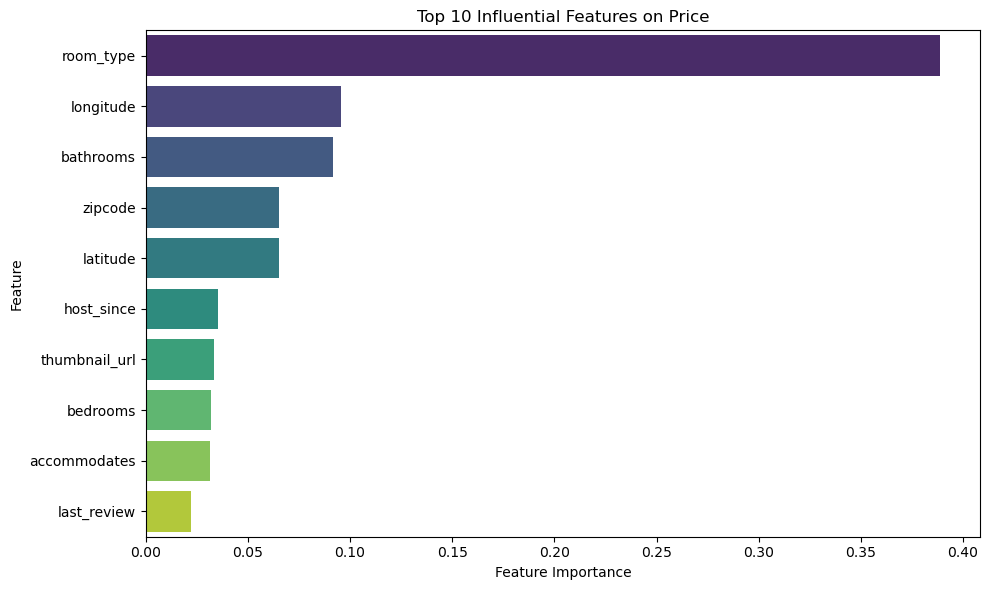

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index, palette='viridis')
plt.title("Top 10 Influential Features on Price")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


VIDEO LINK:
https://drive.google.com/file/d/1qaBleDCP1iMjMNbUPTf-wII0f6kw66g1/view?usp=drivesdk